# FET Model Fitting, Comparison, and Posterior Predictive Checks

This notebook demonstrates the complete workflow with publication-quality visualizations:
1. Load and prepare data
2. Fit all candidate models
3. Compare models using WAIC and fit metrics
4. Generate comprehensive PPC for the winning model
5. Extract and visualize subject-level parameters

**Plotting functions from `plotter.py`:**
- `plot_delta_ic_comparison` - Model comparison (absolute & delta IC)
- `plot_ppc_three_panels` - PPC across threat levels
- `plot_ppc_subject_trials` - Individual subject PPC
- `plot_subject_calibration` - Subject-level calibration
- `plot_histogram_kde` - Distribution visualization
- `plot_scatter` - Accuracy vs Brier scatter
- `plot_calibration` - Overall calibration
- `plot_choice_by_threat_effort` - Choice by threat/effort

## 1. Setup and Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys, glob

ROOT = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
sys.path.insert(0, str(ROOT / 'scripts'))
sys.path.insert(0, str(ROOT / 'scripts' / 'plotting'))

from modeling import (
    configure_device,
    FETExponential, FETHyperbolic, FETLinear, FETQuadratic,
    FETExponentialBias, ThreatOnly, EffortOnly,
    ModelFitter, fit_models_parallel, load_fitted_models,
)
from modeling.ppc import PosteriorPredictive, compare_models, compute_waic
import plotter
from plotter import plot_delta_ic_comparison

OUTPUT_DIR = ROOT / 'results' / 'model_fits' / 'exploratory'
FIGS_DIR = ROOT / 'figs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
print(f"ROOT: {ROOT}")
print(f"Output: {OUTPUT_DIR}")

In [2]:
# Configure device - SET THIS BASED ON YOUR HARDWARE
USE_GPU = True  # Set to False if no GPU available

configure_device(use_gpu=USE_GPU, gpu_memory_fraction=0.9)

GPU configured: cuda:0


CudaDevice(id=0)

## 2. Load Data

In [ ]:
stage5_dirs = sorted(glob.glob(str(ROOT / 'data' / 'exploratory_350' / 'processed' / 'stage5_filtered_data_*')))
if not stage5_dirs:
    raise FileNotFoundError("No stage5 output found. Run notebooks/01_preprocessing/01_run_pipeline.ipynb first.")
STAGE5_DIR = Path(stage5_dirs[-1])
print(f"Loading from: {STAGE5_DIR}")

data = pd.read_csv(STAGE5_DIR / 'behavior.csv')
print(f"Data loaded: {len(data)} trials, {data['subj'].nunique()} subjects")
data.head()

In [4]:
# Quick data summary
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"N subjects: {data['subj'].nunique()}")
print(f"N trials: {len(data)}")
print(f"Trials per subject: {data.groupby('subj').size().mean():.0f}")
print(f"\nThreat levels: {sorted(data['threat'].unique())}")
print(f"Effort H range: [{data['effort_H'].min():.2f}, {data['effort_H'].max():.2f}]")
print(f"Effort L range: [{data['effort_L'].min():.2f}, {data['effort_L'].max():.2f}]")
print(f"Distance H range: [{data['distance_H'].min():.2f}, {data['distance_H'].max():.2f}]")
print(f"Distance L range: [{data['distance_L'].min():.2f}, {data['distance_L'].max():.2f}]")
print(f"\nP(High choice): {data['choice'].mean():.3f}")

DATA SUMMARY
N subjects: 293
N trials: 13185
Trials per subject: 45

Threat levels: [np.float64(0.1), np.float64(0.5), np.float64(0.9)]
Effort H range: [0.60, 1.00]
Effort L range: [0.40, 0.40]
Distance H range: [1.00, 3.00]
Distance L range: [1.00, 1.00]

P(High choice): 0.431


## 3. Define Models to Fit

In [5]:
# Define all candidate models
models_to_fit = {
    # Full models (effort + threat)
    'FET_Exponential': FETExponential(),
    'FET_Hyperbolic': FETHyperbolic(),
    'FET_Linear': FETLinear(),
    'FET_Quadratic': FETQuadratic(),
    
    # Model with bias term
    'FET_Exp_Bias': FETExponentialBias(),
    
    # Ablation models
    'Threat_Only': ThreatOnly(),
    'Effort_Only': EffortOnly(discount='exponential'),
}

print(f"Models to fit: {len(models_to_fit)}")
for name, model in models_to_fit.items():
    print(f"  - {name}: effort={model.use_effort_component}, threat={model.use_threat_component}")

Models to fit: 7
  - FET_Exponential: effort=True, threat=True
  - FET_Hyperbolic: effort=True, threat=True
  - FET_Linear: effort=True, threat=True
  - FET_Quadratic: effort=True, threat=True
  - FET_Exp_Bias: effort=True, threat=True
  - Threat_Only: effort=False, threat=True
  - Effort_Only: effort=True, threat=False


## 4. Fit All Models

Choose between:
- **Parallel fitting**: Faster if you have GPU with enough memory
- **Sequential fitting**: Safer, works on any hardware

In [5]:
# MCMC configuration
MCMC_CONFIG = {
    'num_warmup': 2000,      # Increase for final analysis (e.g., 2000)
    'num_samples': 4000,     # Increase for final analysis (e.g., 2000)
    'num_chains': 4,
    'target_accept_prob': 0.90,
    'R_H': 5.0,
    'R_L': 1.0,
    'C': 5.0,
}

# Choose fitting method
FIT_METHOD = 'sequential'  # 'parallel' or 'sequential'

print(f"MCMC Configuration: {MCMC_CONFIG}")
print(f"Fitting method: {FIT_METHOD}")

MCMC Configuration: {'num_warmup': 2000, 'num_samples': 4000, 'num_chains': 4, 'target_accept_prob': 0.9, 'R_H': 5.0, 'R_L': 1.0, 'C': 5.0}
Fitting method: sequential


In [6]:
%%time
# Fit models
SAVE_DIR = OUTPUT_DIR / 'model_fits_final'

CPU times: user 0 ns, sys: 13 μs, total: 13 μs
Wall time: 15 μs


In [ ]:
%%time

if FIT_METHOD == 'parallel':
    fitted_models = fit_models_parallel(
        models_to_fit,
        data,
        n_parallel=2,
        save_dir=str(SAVE_DIR),
        **MCMC_CONFIG,
        use_gpu=USE_GPU
    )
else:
    fitted_models = {}
    for name, model in models_to_fit.items():
        print(f"\n{'='*60}")
        print(f"Fitting: {name}")
        print(f"{'='*60}")
        
        fitter = ModelFitter(model)
        fitter.fit(data, **MCMC_CONFIG)
        fitter.save(SAVE_DIR / f'{name}_fit.pkl')
        fitted_models[name] = fitter

print(f"\nFitted {len(fitted_models)} models")

## 5. Model Comparison with WAIC

Using `plot_delta_ic_comparison` for publication-quality visualization.

In [7]:
fitted_models, data = load_fitted_models(str(SAVE_DIR), load_data=True)
print(f"Loaded {len(fitted_models)} models")

Loading 7 models from results/model_fits_final...
Data: 13185 trials, 293 subjects
  FET_Quadratic: ['k', 'k_raw', 'z', 'z_raw']
  FET_Hyperbolic: ['k', 'k_raw', 'z', 'z_raw']
  FET_Linear: ['k', 'k_raw', 'z', 'z_raw']
  Threat_Only: ['z', 'z_raw']
  FET_Exp_Bias: ['beta', 'beta_log', 'k', 'k_raw', 'z', 'z_raw']
  Effort_Only: ['k', 'k_raw']
  FET_Exponential: ['k', 'k_raw', 'z', 'z_raw']
Loaded 7 models


In [8]:
# Compute WAIC and comparison metrics for all models
comparison_df = compare_models(fitted_models, data, n_draws=500)

print("\nModel Comparison (sorted by WAIC):")
print("="*80)
display(comparison_df)

Computing model comparison metrics...
  Processing: FET_Quadratic
Generating predictions: 500 draws x 13185 trials
  Chunk 5/5 complete
Predictions complete
  Processing: FET_Hyperbolic
Generating predictions: 500 draws x 13185 trials
  Chunk 5/5 complete
Predictions complete
  Processing: FET_Linear
Generating predictions: 500 draws x 13185 trials
  Chunk 5/5 complete
Predictions complete
  Processing: Threat_Only
Generating predictions: 500 draws x 13185 trials
  Chunk 5/5 complete
Predictions complete
  Processing: FET_Exp_Bias
Generating predictions: 500 draws x 13185 trials
  Chunk 5/5 complete
Predictions complete
  Processing: Effort_Only
Generating predictions: 500 draws x 13185 trials
  Chunk 5/5 complete
Predictions complete
  Processing: FET_Exponential
Generating predictions: 500 draws x 13185 trials
  Chunk 5/5 complete
Predictions complete
Done!

Model Comparison (sorted by WAIC):


,Model,WAIC,dWAIC,WAIC_se,p_waic,lppd,Brier,ECE,McFadden_R2,Accuracy,AUC
0,FET_Exp_Bias,12052.115427,0.000000,120.387571,502.607555,-5523.450158,0.119811,0.023298,0.454300,0.825408,0.911975
1,FET_Exponential,12932.347182,880.231755,116.275340,376.588574,-6089.585017,0.152632,0.070322,0.324438,0.743496,0.862225
2,FET_Quadratic,13088.626964,1036.511537,119.042106,413.480130,-6130.833352,0.151389,0.063811,0.319862,0.788320,0.864599
3,FET_Hyperbolic,13184.922877,1132.807450,113.658880,322.234592,-6270.226846,0.158361,0.095391,0.304398,0.750246,0.855908
4,FET_Linear,13618.012905,1565.897479,112.615859,268.921905,-6540.084548,0.164952,0.105726,0.274461,0.752218,0.848836
5,Threat_Only,14528.544647,2476.429221,110.408371,180.249515,-7084.022809,0.178071,0.113475,0.214118,0.754190,0.820089
6,Effort_Only,16635.984580,4583.869154,75.896727,115.409313,-8202.582977,0.217341,0.110321,0.090028,0.673493,0.728094


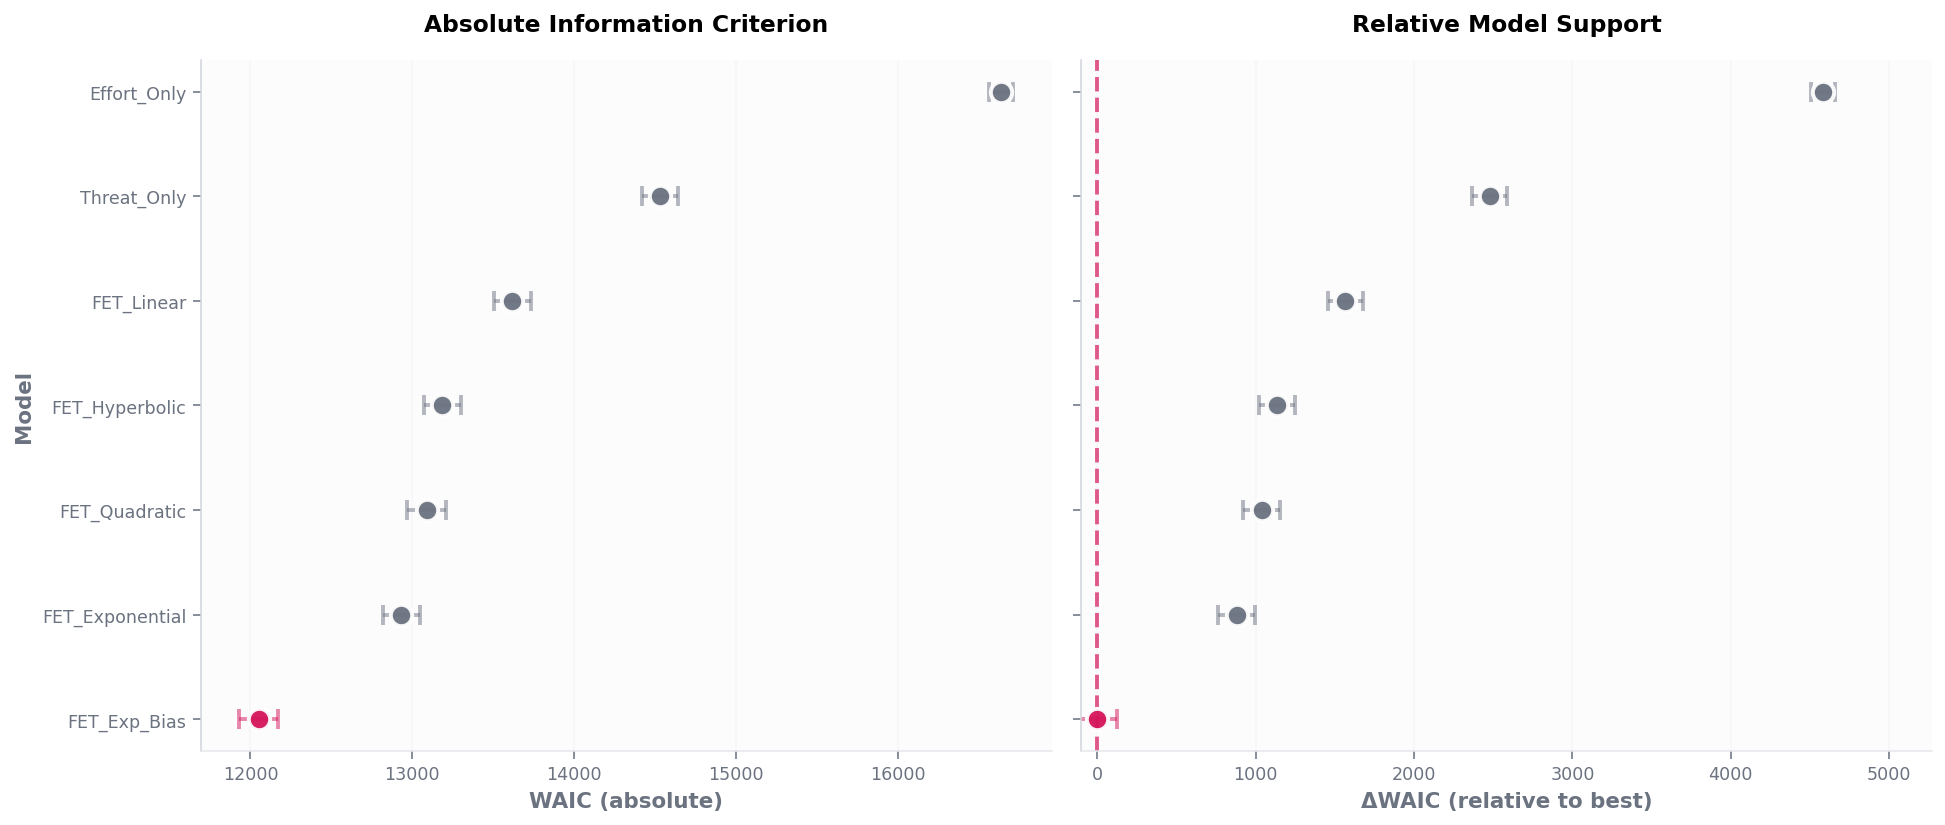


Saved: results/figures/model_comparison_waic.png


In [9]:
# Plot model comparison using plot_delta_ic_comparison
fig, axes = plot_delta_ic_comparison(
    comparison_df,
    metric='WAIC',
    figsize=(14, 6),
    show_absolute=True,
    show_delta=True
)

plt.savefig(FIGURES_DIR / 'model_comparison_waic.png', bbox_inches='tight')
plt.show()

print(f"\nSaved: {FIGURES_DIR / 'model_comparison_waic.png'}")

In [10]:
# Identify winning model
winning_model_name = comparison_df.iloc[0]['Model']
winning_fitter = fitted_models[winning_model_name]

print(f"\n★ Winning model: {winning_model_name}")
print(f"  WAIC: {comparison_df.iloc[0]['WAIC']:.2f}")
print(f"  dWAIC: {comparison_df.iloc[0]['dWAIC']:.2f}")


★ Winning model: FET_Exp_Bias
  WAIC: 12052.12
  dWAIC: 0.00


## 6. Posterior Predictive Checks for Winning Model

Generate comprehensive PPC using plotter functions.

In [11]:
# Generate predictions for winning model
ppc = PosteriorPredictive(winning_fitter)
winning_pred_df, draws = ppc.predict(data, n_draws=500, return_draws=True)

# Compute fit metrics
winning_metrics = ppc.compute_fit_metrics(data, winning_pred_df)

print(f"\n{winning_model_name} Fit Metrics:")
print("="*50)
for metric in ['Brier', 'ECE', 'MCE', 'McFadden_R2', 'Accuracy', 'AUC']:
    print(f"  {metric}: {winning_metrics[metric]:.4f}")

Generating predictions: 500 draws x 13185 trials
  Chunk 5/5 complete
Predictions complete

FET_Exp_Bias Fit Metrics:
  Brier: 0.1198
  ECE: 0.0233
  MCE: 0.0461
  McFadden_R2: 0.4543
  Accuracy: 0.8254
  AUC: 0.9120


### 6.1 Overall Calibration Plot

Using `plot_calibration` to show overall model calibration.

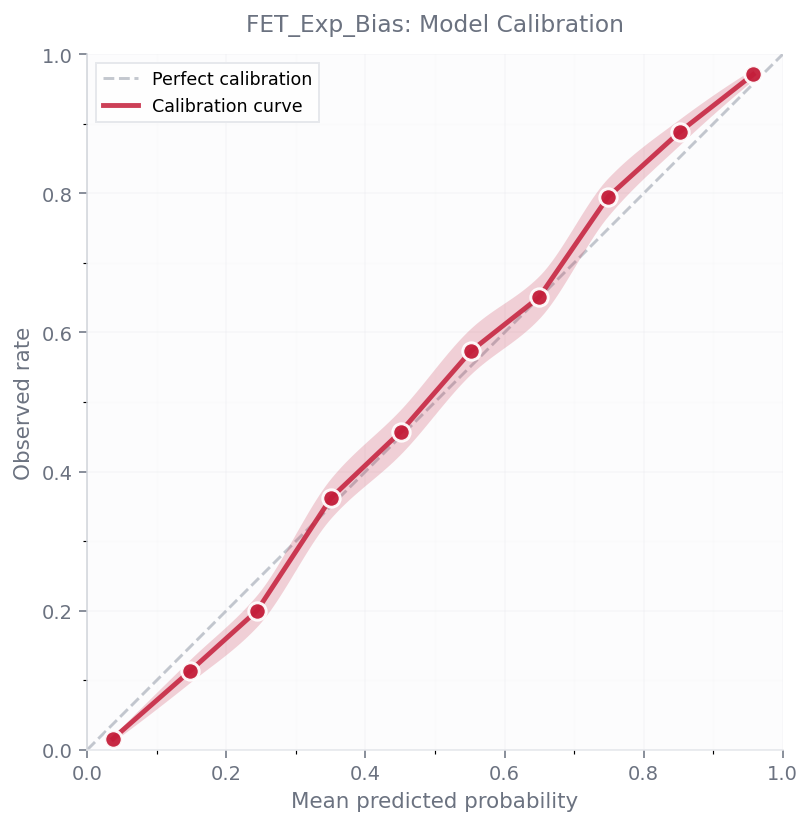

In [12]:
# Plot calibration using plot_calibration
fig, ax = plot_calibration(
    y_true=data['choice'].values,
    y_pred=winning_pred_df['p_high'].values,
    n_bins=10,
    kind='prob',
    title=f'{winning_model_name}: Model Calibration',
    figsize=(6.5, 6),
    show_bars=True,
    bar_style='shaded',
)

plt.savefig(FIGURES_DIR / 'calibration_overall.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.2 PPC Three Panels: Choice by Threat Level

Using `plot_ppc_three_panels` to show P(choose high) vs ΔEffort for each threat level.

In [13]:
# Prepare data for PPC three panels
# Group by threat and delta_effort, compute observed and predicted means

def prepare_ppc_data(data, pred_df, draws):
    """Prepare data for PPC three panel plot."""
    
    # Merge predictions with data
    merged = data.copy()
    merged['p_high_pred'] = pred_df['p_high'].values
    
    # Compute HDI from draws
    if 'p_high' in draws:
        p_high_draws = draws['p_high']  # Shape: (n_draws, n_trials)
    else:
        p_high_draws = None
    
    # Group by threat and delta_effort
    grouped = merged.groupby(['threat', 'delta_effort']).agg({
        'choice': ['mean', 'std', 'count'],
        'p_high_pred': 'mean'
    }).reset_index()
    
    # Flatten columns
    grouped.columns = ['threat', 'delta_effort', 'observed_p_high', 'obs_std', 'n_trials', 'ppc_mean']
    
    # Compute HDI for each cell if draws available
    if p_high_draws is not None:
        hdi_low_95, hdi_high_95 = [], []
        hdi_low_50, hdi_high_50 = [], []
        
        for _, row in grouped.iterrows():
            mask = (merged['threat'] == row['threat']) & \
                   (merged['delta_effort'] == row['delta_effort'])
            cell_draws = p_high_draws[:, mask.values].mean(axis=1)  # Average across trials in cell
            
            hdi_low_95.append(np.percentile(cell_draws, 2.5))
            hdi_high_95.append(np.percentile(cell_draws, 97.5))
            hdi_low_50.append(np.percentile(cell_draws, 25))
            hdi_high_50.append(np.percentile(cell_draws, 75))
        
        grouped['ppc_hdi_low'] = hdi_low_95
        grouped['ppc_hdi_high'] = hdi_high_95
        grouped['ppc_hdi50_low'] = hdi_low_50
        grouped['ppc_hdi50_high'] = hdi_high_50
    else:
        # Use SE-based CI
        grouped['ppc_hdi_low'] = grouped['ppc_mean'] - 1.96 * grouped['obs_std'] / np.sqrt(grouped['n_trials'])
        grouped['ppc_hdi_high'] = grouped['ppc_mean'] + 1.96 * grouped['obs_std'] / np.sqrt(grouped['n_trials'])
        grouped['ppc_hdi50_low'] = grouped['ppc_mean'] - 0.67 * grouped['obs_std'] / np.sqrt(grouped['n_trials'])
        grouped['ppc_hdi50_high'] = grouped['ppc_mean'] + 0.67 * grouped['obs_std'] / np.sqrt(grouped['n_trials'])
    
    return grouped

ppc_data = prepare_ppc_data(data, winning_pred_df, draws)
print("PPC data prepared:")
display(ppc_data)

PPC data prepared:


,threat,delta_effort,observed_p_high,obs_std,n_trials,ppc_mean,ppc_hdi_low,ppc_hdi_high,ppc_hdi50_low,ppc_hdi50_high
0,0.1,0.2,0.808191,0.393858,1465,0.848873,0.839302,0.858104,0.845022,0.852499
1,0.1,0.4,0.692150,0.461762,1465,0.712210,0.701186,0.721399,0.708630,0.715869
2,0.1,0.6,0.565188,0.495902,1465,0.578274,0.563427,0.593157,0.572983,0.584019
3,0.5,0.2,0.633447,0.482027,1465,0.623722,0.612353,0.634659,0.619454,0.627962
4,0.5,0.4,0.380887,0.485771,1465,0.326968,0.316140,0.337662,0.323396,0.330698
5,0.5,0.6,0.187713,0.390616,1465,0.192205,0.181491,0.204166,0.188238,0.196142
6,0.9,0.2,0.397270,0.489500,1465,0.378307,0.362982,0.392702,0.372843,0.383810
7,0.9,0.4,0.137884,0.344896,1465,0.152043,0.143687,0.160834,0.149029,0.154808
8,0.9,0.6,0.078498,0.269046,1465,0.086751,0.079423,0.094823,0.083815,0.089422


In [14]:
import importlib
import plotter  # or whatever your module import is

from plotter import plot_ppc_three_panels

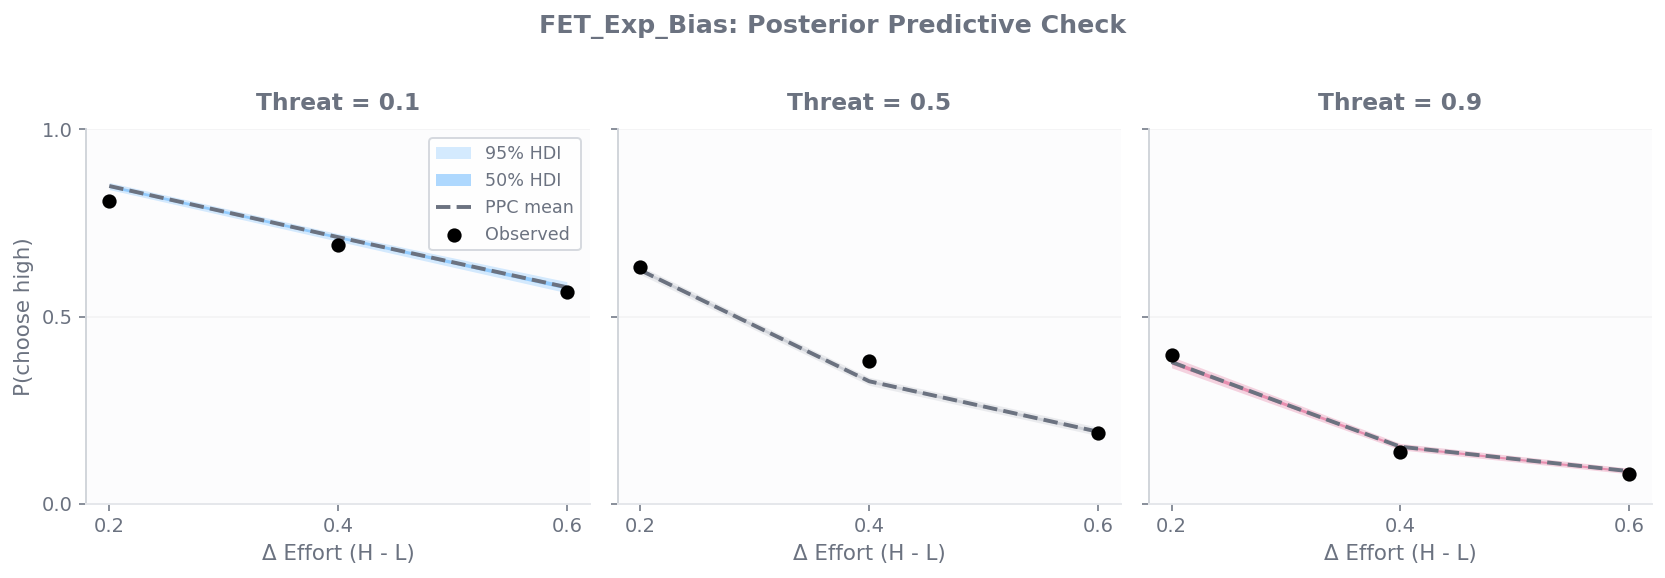

In [15]:
# Plot PPC three panels
threat_levels = sorted(data['threat'].unique())

fig, axes = plot_ppc_three_panels(
    ppc_data,
    threats=threat_levels[:3],  # Use up to 3 threat levels
    threat_col='threat',
    delta_effort_col='delta_effort',
    mean_col='ppc_mean',
    observed_col='observed_p_high',
    hdi95_cols=('ppc_hdi_low', 'ppc_hdi_high'),
    hdi50_cols=('ppc_hdi50_low', 'ppc_hdi50_high'),
    figsize=(12, 4),
    ylim=(0.0, 1.0),
    title=f'{winning_model_name}: Posterior Predictive Check'
)

plt.savefig(FIGURES_DIR / 'ppc_three_panels.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.3 Choice by Threat and Effort (Grouped Bar Chart)

Using `plot_choice_by_threat_effort` for observed vs predicted comparison.

In [16]:
import importlib
import plotter  # or whatever your module import is

importlib.reload(plotter)
from plotter import plot_choice_by_threat_effort



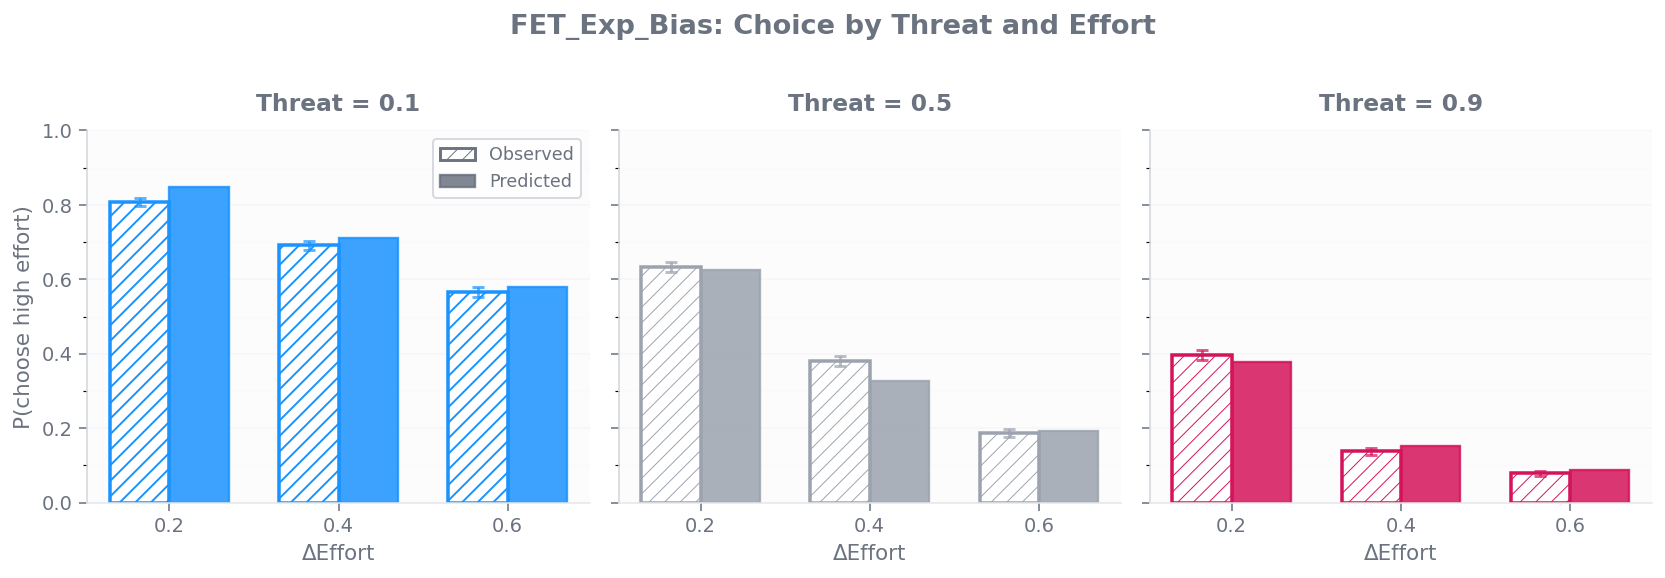

In [17]:
# Prepare data for grouped bar chart
bar_data = ppc_data.rename(columns={
    'observed_p_high': 'p_high_effort_obs',
    'ppc_mean': 'p_high_effort_pred'
})

# Add SE columns if needed
bar_data['obs_se'] = bar_data['obs_std'] / np.sqrt(bar_data['n_trials'])

fig, axes, summary = plot_choice_by_threat_effort(
    bar_data,
    threat_col='threat',
    delta_effort_col='delta_effort',
    observed_col='p_high_effort_obs',
    predicted_col='p_high_effort_pred',
    threat_levels=threat_levels[:3],
    error_col_obs='obs_se',
    figsize=(12, 4),
    ylabel='P(choose high effort)',
    title=f'{winning_model_name}: Choice by Threat and Effort'
)

plt.savefig(FIGURES_DIR / 'choice_by_threat_effort.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.4 Subject-Level Calibration

Using `plot_subject_calibration` to show per-subject calibration.

In [18]:
# Compute subject-level metrics
subj_metrics = ppc.compute_subject_metrics(data, winning_pred_df)
print("Subject-level metrics:")
display(subj_metrics.head(10))

Subject-level metrics:


,subj,accuracy,brier,log_lik,mean_p_high,mean_choice,n_trials
0,1,0.866667,0.085344,-12.031408,0.335015,0.333333,45.0
1,2,0.888889,0.076761,-11.114833,0.174650,0.133333,45.0
2,3,0.800000,0.161671,-22.588282,0.416708,0.422222,45.0
3,4,0.955556,0.038664,-7.023884,0.479244,0.488889,45.0
4,5,0.822222,0.132732,-18.915529,0.696634,0.711111,45.0
5,6,0.844444,0.104349,-14.581686,0.337624,0.333333,45.0
6,7,0.755556,0.156540,-20.929524,0.380916,0.377778,45.0
7,8,0.888889,0.094015,-13.820649,0.169831,0.133333,45.0
8,9,0.577778,0.243935,-30.757748,0.370263,0.400000,45.0
9,10,1.000000,0.003141,-1.688568,0.326328,0.333333,45.0


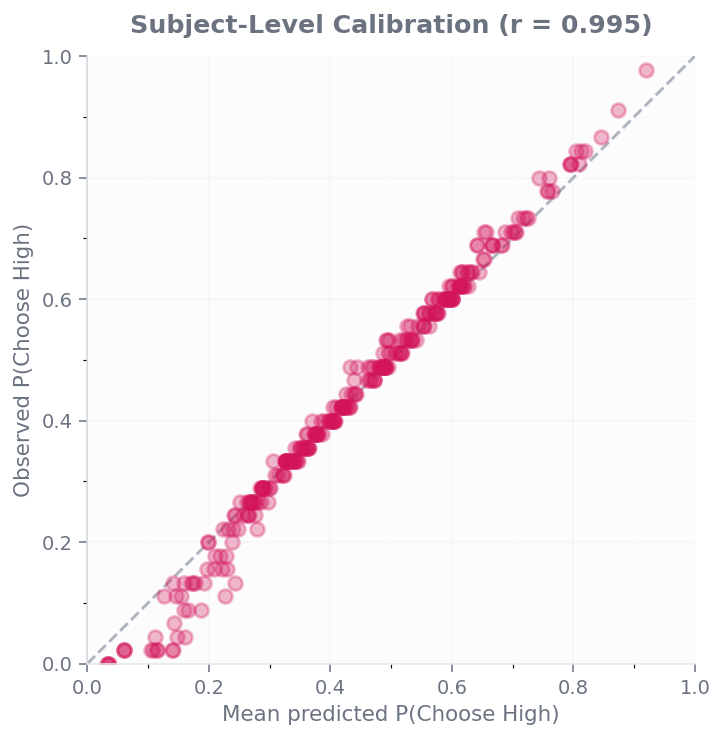


Subject-level calibration: r = 0.995, p = 0.0000


In [19]:
# Plot subject-level calibration
fig, ax, (r, p, n) = plot_subject_calibration(
    mean_pred=subj_metrics['mean_p_high'].values,
    observed=subj_metrics['mean_choice'].values,  # observed_p_high = mean_choice,
    xlabel='Mean predicted P(Choose High)',
    ylabel='Observed P(Choose High)',
    title='Subject-Level Calibration',
    figsize=(5, 5)
)

plt.savefig(FIGURES_DIR / 'subject_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSubject-level calibration: r = {r:.3f}, p = {p:.4f}")

### 6.5 Accuracy Distribution with KDE

Using `plot_histogram_kde` to show subject accuracy distribution.

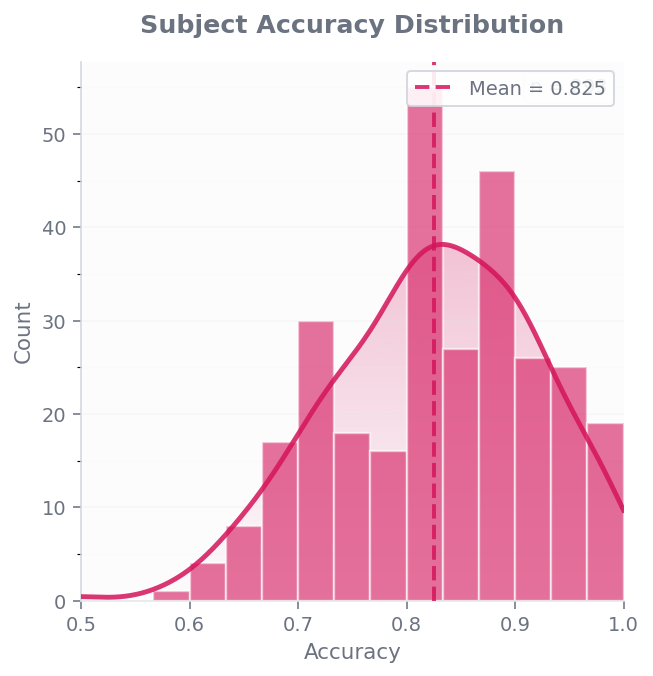


Accuracy stats: mean=0.825, std=0.094, n=293


In [20]:
# Plot subject accuracy distribution
fig, ax, stats = plot_histogram_kde(
    subj_metrics['accuracy'].values,
    n_bins=15,
    title='Subject Accuracy Distribution',
    xlabel='Accuracy',
    ylabel='Count',
    figsize=(5, 5),
    show_kde=True,
    show_mean=True,
    xlim=(0.5, 1.0),
    color=Colors.RUBY1,

)

plt.savefig(FIGURES_DIR / 'accuracy_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAccuracy stats: mean={stats['mean']:.3f}, std={stats['std']:.3f}, n={stats['n']}")

### 6.6 Accuracy vs Brier Score Scatter

Using `plot_scatter` to show relationship between accuracy and Brier score.

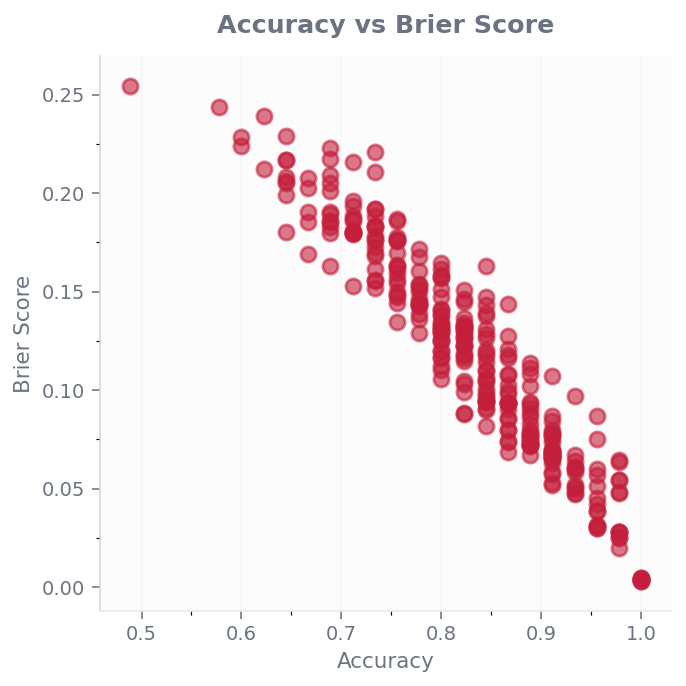

In [21]:
# Plot accuracy vs Brier scatter
fig, ax = plot_scatter(
    x=subj_metrics['accuracy'].values,
    y=subj_metrics['brier'].values,
    xlabel='Accuracy',
    ylabel='Brier Score',
    title='Accuracy vs Brier Score',
    figsize=(5, 5),
    point_alpha=0.6,
    point_size=60,

)

plt.savefig(FIGURES_DIR / 'accuracy_vs_brier.png', dpi=300, bbox_inches='tight')
plt.show()

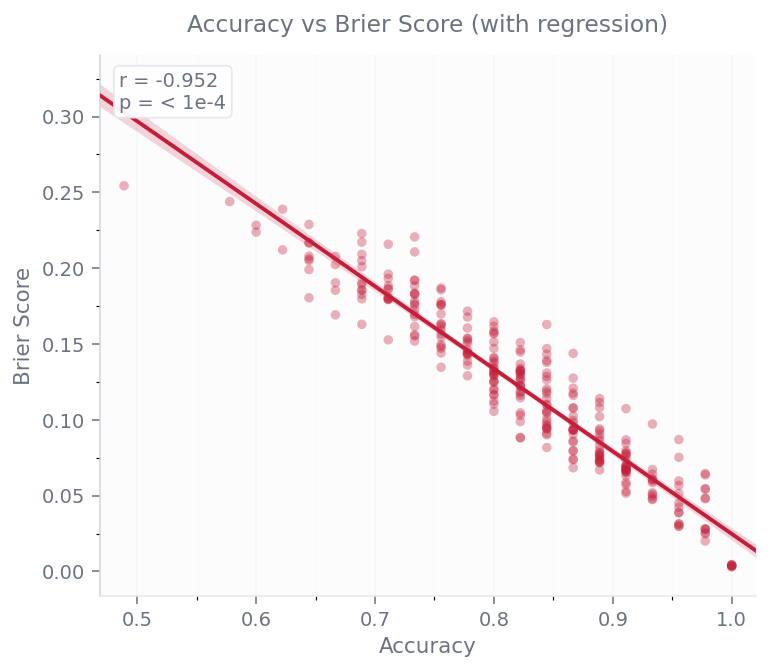

Correlation: r = -0.952, p = 0.0000


In [22]:
# Also show as correlation plot with regression line
fig, ax, (r, p, n) = plot_corr(
    x=subj_metrics['accuracy'].values,
    y=subj_metrics['brier'].values,
    xlabel='Accuracy',
    ylabel='Brier Score',
)

ax.set_title('Accuracy vs Brier Score (with regression)', 
             fontsize=12, color=Colors.INK, pad=12)

plt.savefig(FIGURES_DIR / 'accuracy_vs_brier_corr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Correlation: r = {r:.3f}, p = {p:.4f}")

## 7. Extract Subject-Level Parameters

In [23]:
# Get population parameters
pop_params = winning_fitter.get_population_params()

print("Population-level Parameters:")
print("="*60)
display(pop_params)

Population-level Parameters:


,parameter,mean,median,std,hdi_lower,hdi_upper
0,tau,0.437430,0.435721,0.032960,0.377222,0.498908
1,mu_k,1.538963,1.536698,0.121789,1.308320,1.762898
2,sigma_k,0.808246,0.803244,0.070254,0.677104,0.939500
3,mu_z,0.297789,0.296814,0.035699,0.232647,0.365479
4,sigma_z,0.688866,0.685409,0.066613,0.567158,0.814657
5,mu_beta_log,-0.188161,-0.187524,0.084772,-0.349869,-0.030490
6,sigma_beta_log,0.957196,0.955944,0.056678,0.853807,1.066426


In [24]:
# Get subject-level parameters
available_params = [k for k in winning_fitter.model.posterior_samples.keys() 
                    if k in ['k', 'z', 'beta']]

print(f"Available subject-level parameters: {available_params}")

subject_params = {}
for param in available_params:
    subject_params[param] = winning_fitter.get_subject_params(param)
    print(f"\n{param.upper()} parameters:")
    display(subject_params[param].head(10))

Available subject-level parameters: ['beta', 'k', 'z']

BETA parameters:


,subject,mean,median,std,hdi_lower,hdi_upper
0,1,2.220687,2.156571,0.714246,1.029207,3.652346
1,2,0.893810,0.834090,0.448609,0.148256,1.715819
2,3,0.350889,0.317026,0.194931,0.044657,0.704614
3,4,2.204635,2.169792,0.597231,1.099327,3.308507
4,5,0.462267,0.422765,0.249022,0.062311,0.910418
5,6,1.767853,1.717527,0.608492,0.690408,2.928108
6,7,1.184282,1.149772,0.461474,0.361948,2.051184
7,8,1.553452,1.477036,0.640052,0.412862,2.739282
8,9,0.359614,0.329754,0.189948,0.055943,0.703029
9,10,6.159539,5.798142,2.029114,2.861034,9.883401



K parameters:


,subject,mean,median,std,hdi_lower,hdi_upper
0,1,1.343926,1.299873,0.425430,0.607454,2.122816
1,2,3.871102,3.886187,0.965258,2.347983,5.000000
2,3,2.323839,2.218509,0.637409,1.300618,3.435865
3,4,0.579746,0.551900,0.251709,0.155599,1.049068
4,5,0.920305,0.905191,0.288357,0.391484,1.459440
5,6,1.579261,1.509840,0.516701,0.737502,2.470440
6,7,1.948642,1.822642,0.663650,0.909135,3.085188
7,8,4.172500,4.384531,0.863181,2.686816,5.000000
8,9,4.115241,4.323120,0.903019,2.577641,5.000000
9,10,0.572749,0.540551,0.253404,0.139791,1.035397



Z parameters:


,subject,mean,median,std,hdi_lower,hdi_upper
0,1,0.418497,0.384819,0.216701,0.100000,0.800847
1,2,1.275564,1.180379,0.627937,0.168561,2.456679
2,3,0.397443,0.377405,0.173335,0.100000,0.688057
3,4,0.378309,0.363482,0.161401,0.100000,0.647731
4,5,0.255403,0.243824,0.105897,0.100000,0.436693
5,6,0.407188,0.379617,0.200537,0.100000,0.758231
6,7,0.259356,0.239001,0.123029,0.100000,0.475091
7,8,0.438026,0.399262,0.233726,0.100000,0.845558
8,9,0.166377,0.149901,0.067062,0.100000,0.287176
9,10,0.288264,0.251578,0.160709,0.100000,0.581388


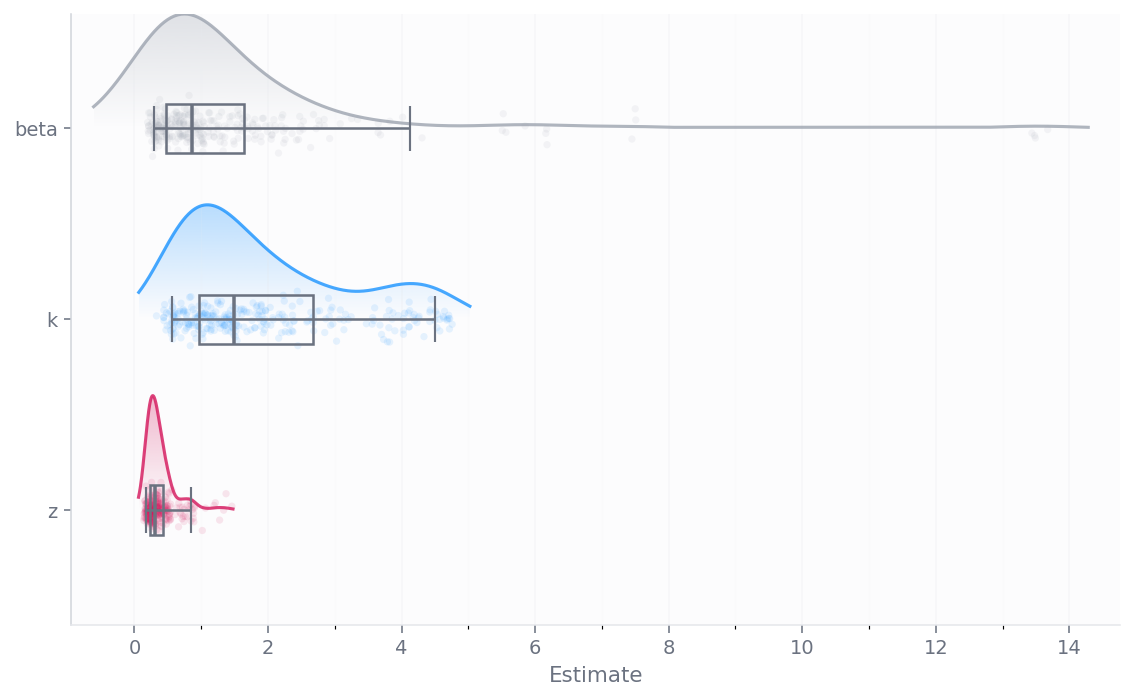

In [25]:
importlib.reload(plotter)
from plotter import plot_parameter_half_violin_glow

# Combine them into one wide DataFrame
param_df = subject_params['z'][['subject']].copy()
param_df['z_mean'] = subject_params['z']['mean'].values
param_df['k_mean'] = subject_params['k']['mean'].values
param_df['beta_mean'] = subject_params['beta']['mean'].values

# Then plot
fig, ax = plot_parameter_half_violin_glow(param_df, params=('z', 'k', 'beta'),side="upper")
plt.savefig(FIGURES_DIR / 'parameters_distribution.png', dpi=300, bbox_inches='tight')


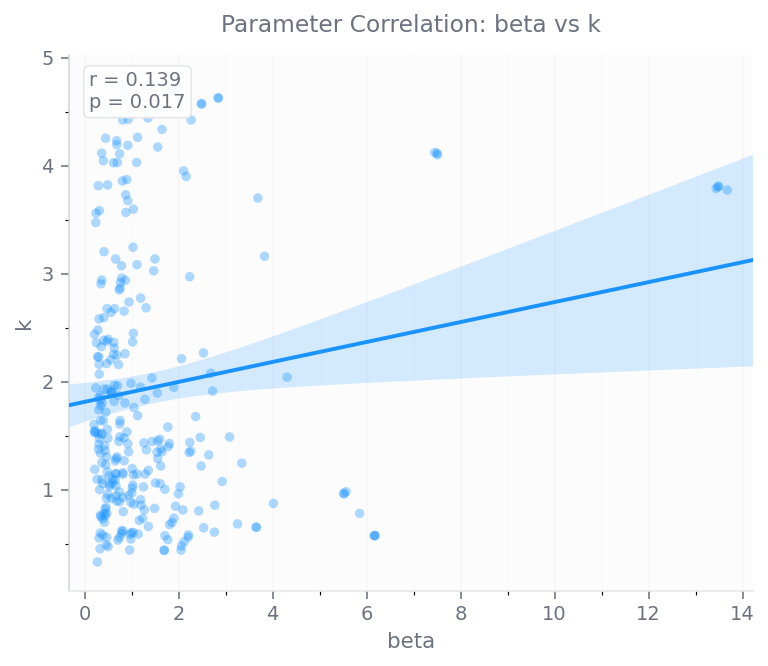

beta vs k: r = 0.139, p = 0.0171


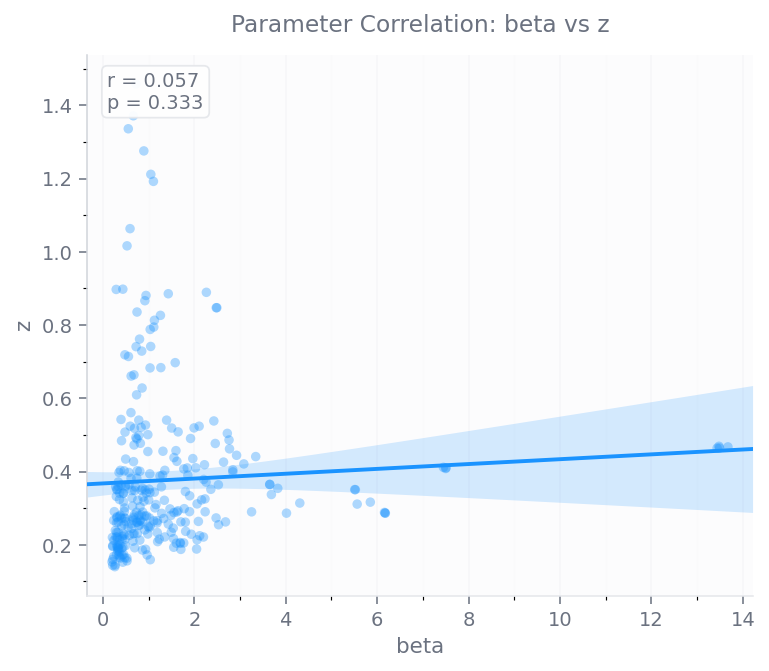

beta vs z: r = 0.057, p = 0.3327


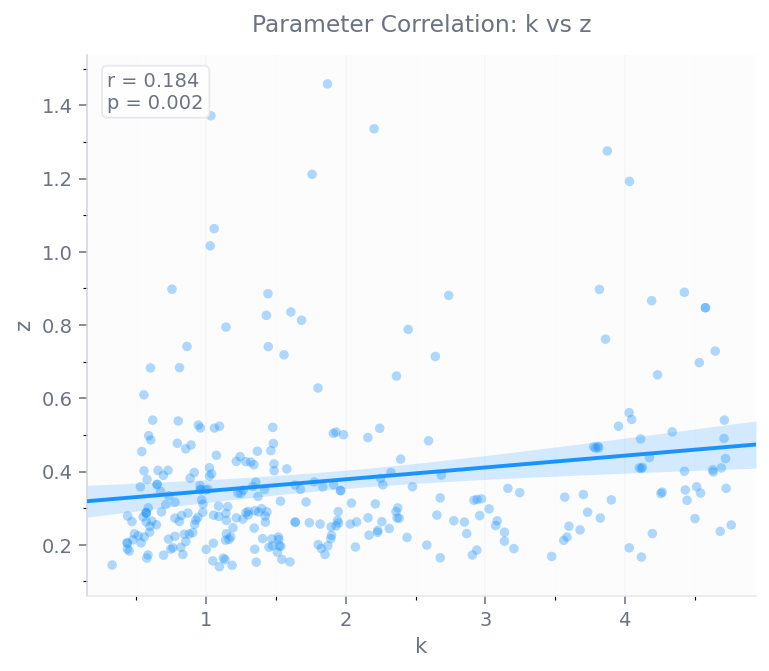

k vs z: r = 0.184, p = 0.0015


In [26]:
# Parameter correlations (if multiple subject-level params available)
if len(available_params) >= 2:
    # Combine into single DataFrame
    combined_params = subject_params[available_params[0]][['subject', 'mean']].rename(
        columns={'mean': available_params[0]})
    
    for param in available_params[1:]:
        param_means = subject_params[param][['subject', 'mean']].rename(
            columns={'mean': param})
        combined_params = combined_params.merge(param_means, on='subject')
    
    # Plot correlation between parameters
    for i, param1 in enumerate(available_params):
        for param2 in available_params[i+1:]:
            fig, ax, (r, p, n) = plot_corr(
                x=combined_params[param1].values,
                y=combined_params[param2].values,
                xlabel=f'{param1}',
                ylabel=f'{param2}',
                colorset_hex=Colors.CERULEAN2
            )
            ax.set_title(f'Parameter Correlation: {param1} vs {param2}',
                        fontsize=12, color=Colors.INK, pad=12)
            
            plt.savefig(FIGURES_DIR / f'param_corr_{param1}_{param2}.png', 
                       dpi=300, bbox_inches='tight')
            plt.show()
            print(f"{param1} vs {param2}: r = {r:.3f}, p = {p:.4f}")

## 8. Individual Subject PPC

Using `plot_ppc_subject_trials` for detailed individual subject visualization.

In [27]:
# Select subjects for detailed PPC visualization
# Pick subjects with varying accuracy levels
n_example_subjects = 2
sorted_subjs = subj_metrics.sort_values('accuracy')['subj'].values

# Select evenly spaced subjects across accuracy range
indices = np.linspace(0, len(sorted_subjs)-1, n_example_subjects, dtype=int)
example_subjects = sorted_subjs[indices].tolist()

print(f"Example subjects for detailed PPC: {example_subjects}")

Example subjects for detailed PPC: [210, 25]


In [28]:
# Prepare data for subject trials plot
# Merge predicted values with original data
df_with_pred = data.copy()
df_with_pred['p_high_pred'] = winning_pred_df['p_high'].values
df_with_pred['SV_H'] = winning_pred_df['SV_H'].values
df_with_pred['SV_L'] = winning_pred_df['SV_L'].values
df_with_pred['delta_sv'] = df_with_pred['SV_H'] - df_with_pred['SV_L']

# For the plotter, we need vigor-like data - use p_high_pred as proxy
df_with_pred['log_vigor'] = np.log(df_with_pred['p_high_pred'] + 0.01)
df_with_pred['outcome'] = 1 - df_with_pred['choice']  # Placeholder for captures

# Create predicted dataframe
df_predicted = df_with_pred[['subj', 'trial', 'p_high_pred', 'delta_sv']].copy()
df_predicted = winning_pred_df[['p_high', 'SV_H', 'SV_L', 'S_u_H']].copy()
df_predicted['subj'] = data['subj'].values
df_predicted['trial'] = data['trial'].values
df_predicted['delta_sv'] = df_predicted['SV_H'] - df_predicted['SV_L']


print("Data prepared for subject PPC plots")

Data prepared for subject PPC plots


In [29]:
importlib.reload(plotter)
from plotter import plot_ppc_subject_trials


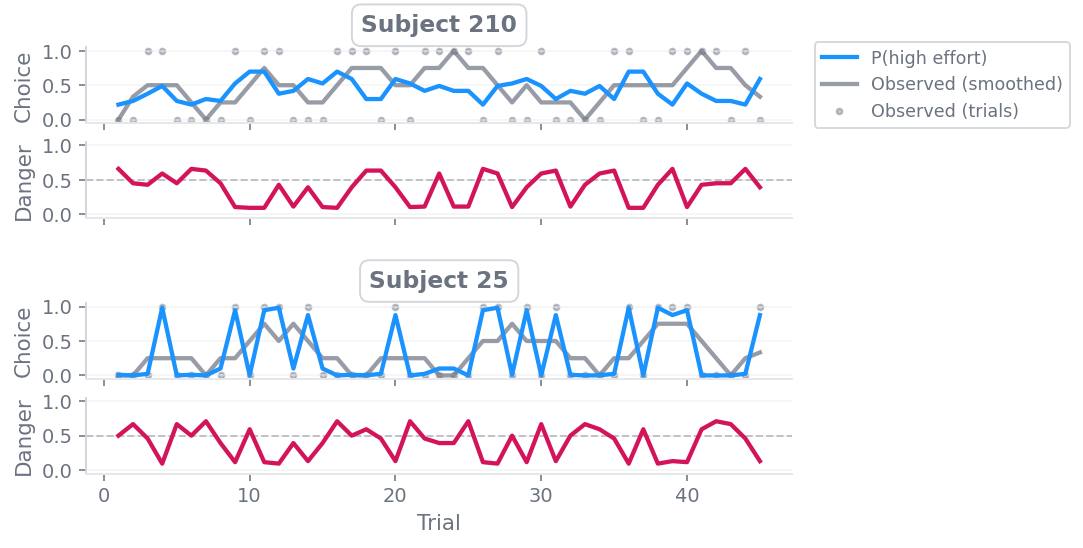

In [30]:
# Plot individual subject trials
fig, axes = plot_ppc_subject_trials(
    df_with_pred,
    df_predicted=df_predicted,
    subjects=example_subjects,
    max_trials=50,
    features=['choice', 'survival'],
    legend_position='outside_right',
    figsize=(6, 3.5),
    inter_subject_gap=0.5, intra_feature_gap=0.25,
)

plt.savefig(FIGURES_DIR / 'ppc_subject_trials.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Save Results

In [31]:
# Save comparison table (includes WAIC)
comparison_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'model_comparison.csv'}")

# Save winning model predictions
winning_pred_df.to_csv(OUTPUT_DIR / f'{winning_model_name}_predictions.csv', index=False)
print(f"Saved: {OUTPUT_DIR / f'{winning_model_name}_predictions.csv'}")

# Save subject-level metrics
subj_metrics.to_csv(OUTPUT_DIR / f'{winning_model_name}_subject_metrics.csv', index=False)
print(f"Saved: {OUTPUT_DIR / f'{winning_model_name}_subject_metrics.csv'}")

# Save subject-level parameters
for param in available_params:
    subject_params[param].to_csv(OUTPUT_DIR / f'{winning_model_name}_{param}_params.csv', index=False)
    print(f"Saved: {OUTPUT_DIR / f'{winning_model_name}_{param}_params.csv'}")

# Save population parameters
pop_params.to_csv(OUTPUT_DIR / f'{winning_model_name}_population_params.csv', index=False)
print(f"Saved: {OUTPUT_DIR / f'{winning_model_name}_population_params.csv'}")

# Save PPC summary data
ppc_data.to_csv(OUTPUT_DIR / f'{winning_model_name}_ppc_summary.csv', index=False)
print(f"Saved: {OUTPUT_DIR / f'{winning_model_name}_ppc_summary.csv'}")

print(f"\n✓ All results saved to: {OUTPUT_DIR}")
print(f"✓ All figures saved to: {FIGURES_DIR}")

Saved: results/model_comparison.csv
Saved: results/FET_Exp_Bias_predictions.csv
Saved: results/FET_Exp_Bias_subject_metrics.csv
Saved: results/FET_Exp_Bias_beta_params.csv
Saved: results/FET_Exp_Bias_k_params.csv
Saved: results/FET_Exp_Bias_z_params.csv
Saved: results/FET_Exp_Bias_population_params.csv
Saved: results/FET_Exp_Bias_ppc_summary.csv

✓ All results saved to: results
✓ All figures saved to: results/figures


## 10. Summary

In [32]:
print("="*70)
print("ANALYSIS SUMMARY")
print("="*70)
print(f"\nData: {len(data)} trials, {data['subj'].nunique()} subjects")
print(f"\nModels compared: {len(fitted_models)}")
for i, row in comparison_df.iterrows():
    marker = '★' if i == 0 else ' '
    print(f"  {marker} {row['Model']}: WAIC = {row['WAIC']:.1f}, dWAIC = {row['dWAIC']:.1f}")

print(f"\n{'='*70}")
print(f"WINNING MODEL: {winning_model_name}")
print(f"{'='*70}")
print(f"  WAIC:        {comparison_df.iloc[0]['WAIC']:.2f}")
print(f"  McFadden R²: {winning_metrics['McFadden_R2']:.4f}")
print(f"  Accuracy:    {winning_metrics['Accuracy']:.4f}")
print(f"  AUC:         {winning_metrics['AUC']:.4f}")
print(f"  Brier:       {winning_metrics['Brier']:.4f}")
print(f"  ECE:         {winning_metrics['ECE']:.4f}")

print(f"\nSubject-level parameters: {available_params}")

print(f"\n{'='*70}")
print("GENERATED FIGURES:")
print(f"{'='*70}")
for fig_file in FIGURES_DIR.glob('*.png'):
    print(f"  • {fig_file.name}")

print(f"\nResults saved to: {OUTPUT_DIR}")
print("="*70)

ANALYSIS SUMMARY

Data: 13185 trials, 293 subjects

Models compared: 7
  ★ FET_Exp_Bias: WAIC = 12052.1, dWAIC = 0.0
    FET_Exponential: WAIC = 12932.3, dWAIC = 880.2
    FET_Quadratic: WAIC = 13088.6, dWAIC = 1036.5
    FET_Hyperbolic: WAIC = 13184.9, dWAIC = 1132.8
    FET_Linear: WAIC = 13618.0, dWAIC = 1565.9
    Threat_Only: WAIC = 14528.5, dWAIC = 2476.4
    Effort_Only: WAIC = 16636.0, dWAIC = 4583.9

WINNING MODEL: FET_Exp_Bias
  WAIC:        12052.12
  McFadden R²: 0.4543
  Accuracy:    0.8254
  AUC:         0.9120
  Brier:       0.1198
  ECE:         0.0233

Subject-level parameters: ['beta', 'k', 'z']

GENERATED FIGURES:
  • choice_by_threat_effort.png
  • param_corr_beta_z.png
  • model_comparison_waic.png
  • param_corr_beta_k.png
  • parameters_distribution.png
  • param_corr_k_z.png
  • ppc_subject_trials.png
  • calibration_overall.png
  • accuracy_vs_brier_corr.png
  • ppc_three_panels.png
  • subject_calibration.png
  • accuracy_vs_brier.png
  • accuracy_distribution